# sctrial: Scalability Analysis (Real Data)

This notebook benchmarks `sctrial` on a **real longitudinal immunotherapy dataset** (Sade‑Feldman et al., Cell 2018; GSE120575). The focus is **scalability and correctness** on a realistic analysis pipeline.


## Objective
- Use a real biological dataset (no synthetic labels)
- Apply participant‑level aggregation to avoid pseudoreplication
- Run a comprehensive pipeline: cross‑sectional, within‑arm, DiD, abundance, and gene‑set analysis
- Record runtimes for key steps

- To keep runtime manageable, we optionally subsample cells per participant‑visit


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import scipy.sparse as sp
import sctrial as st
from statsmodels.stats.multitest import multipletests

pd.options.mode.chained_assignment = None
sc.settings.verbosity = 0  # Suppress scanpy output

# Configuration
SEED = 42
MIN_GENES_FOR_SCORE = 5
MIN_PAIRED_PER_ARM = 3
FDR_ALPHA = 0.25
MAX_CELLS_PER_PARTICIPANT_VISIT = 500
MAX_GENES_FOR_DID = 2000  # runtime cap for genome-wide DiD

benchmark_times = {}

## 1. Load and preprocess dataset (Sade‑Feldman melanoma immunotherapy)


In [2]:
# Dataset loader (from sctrial)
from sctrial.datasets import load_sade_feldman


## 2. Load data, harmonize response labels, and define trial design


In [3]:
t0 = time.perf_counter()
adata = load_sade_feldman(max_cells_per_participant_visit=MAX_CELLS_PER_PARTICIPANT_VISIT, processed_name="sade_feldman_processed_v5_subsample.h5ad")
benchmark_times["load_data"] = time.perf_counter() - t0

# Harmonize response labels at participant level (majority label)
resp_counts = (
    adata.obs
    .groupby(["participant_id", "response"], observed=True)
    .size()
    .reset_index(name="n_cells")
)
resp_n = resp_counts.groupby("participant_id")["response"].nunique()
mixed_ids = resp_n[resp_n > 1].index.tolist()

dominant_response = (
    resp_counts
    .sort_values(["participant_id", "n_cells"], ascending=[True, False])
    .drop_duplicates("participant_id")
    .set_index("participant_id")["response"]
)

RESPONSE_COL = "response_harmonized"
adata.obs[RESPONSE_COL] = adata.obs["participant_id"].map(dominant_response)

# Paired participants
visit_col = "visit"
adata.obs[visit_col] = adata.obs[visit_col].astype(str)
visits = [v for v in ["Pre", "Post"] if v in adata.obs[visit_col].unique()]

participant_summary = (
    adata.obs.groupby("participant_id")[visit_col].apply(set).reset_index()
)
participant_summary["has_Pre"] = participant_summary[visit_col].apply(lambda x: "Pre" in x)
participant_summary["has_Post"] = participant_summary[visit_col].apply(lambda x: "Post" in x)
participant_summary["is_paired"] = participant_summary["has_Pre"] & participant_summary["has_Post"]
participant_summary[RESPONSE_COL] = participant_summary["participant_id"].map(dominant_response)

paired_ids = set(participant_summary.loc[participant_summary["is_paired"], "participant_id"])
paired_by_response = (
    participant_summary[participant_summary["is_paired"]]
    .groupby(RESPONSE_COL)
    .size()
    .to_dict()
)

print("Dataset summary:")
print(f"  Cells: {adata.n_obs:,}")
print(f"  Genes: {adata.n_vars:,}")
print(f"  Participants: {adata.obs['participant_id'].nunique()}")
print(f"  Mixed-response participants: {len(mixed_ids)}")
print(f"  Paired participants: {len(paired_ids)}")
print(f"  Paired by response: {paired_by_response}")

adata_paired = adata[adata.obs["participant_id"].isin(paired_ids)].copy()

# Trial design
# Note: "Responder" is treated, "Non-responder" is control for DiD interpretation
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col=visit_col,
    arm_col=RESPONSE_COL,
    arm_treated="Responder",
    arm_control="Non-responder",
    celltype_col="cell_type",
)


Loaded processed Sade-Feldman dataset: 12,187 cells, 55,737 genes
Dataset summary:
  Cells: 12,187
  Genes: 55,737
  Participants: 25
  Mixed-response participants: 3
  Paired participants: 10
  Paired by response: {'Non-responder': 7, 'Responder': 3}


## 3. Exploratory overview (paired participants)


Cells per response x visit:


visit,Post,Pre
response_harmonized,,
Non-responder,2765,2164
Responder,1231,908


Participants per response x visit:


visit,Post,Pre
response_harmonized,,
Non-responder,7,7
Responder,3,3


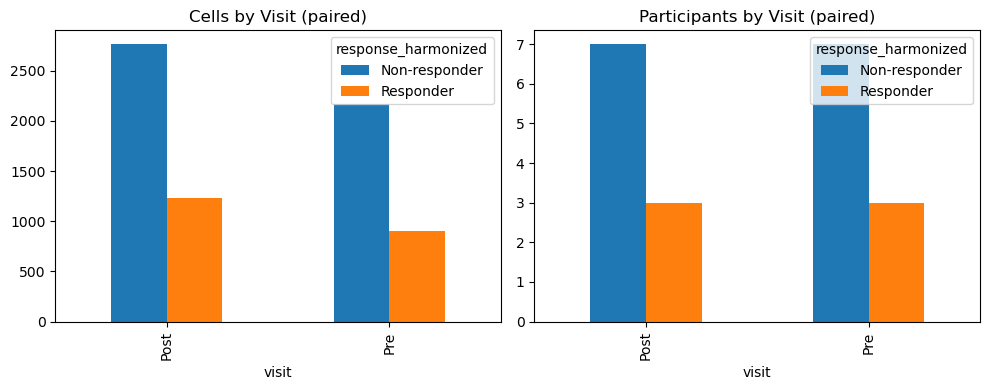

In [4]:
cell_counts = adata_paired.obs.groupby([RESPONSE_COL, visit_col], observed=True).size().unstack(fill_value=0)
pt_counts = adata_paired.obs.groupby([RESPONSE_COL, visit_col], observed=True)["participant_id"].nunique().unstack(fill_value=0)

print("Cells per response x visit:")
display(cell_counts)
print("Participants per response x visit:")
display(pt_counts)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cell_counts.T.plot(kind="bar", ax=axes[0], title="Cells by Visit (paired)")
pt_counts.T.plot(kind="bar", ax=axes[1], title="Participants by Visit (paired)")
plt.tight_layout(); plt.show()


## 4. Gene signatures (for interpretability + benchmarking)


In [5]:
available = set(adata_paired.var_names)

raw_signatures = {
    "Cytotoxicity": ["GZMB", "GZMA", "GZMH", "GZMK", "PRF1", "GNLY", "IFNG", "NKG7", "KLRD1", "KLRB1", "FASLG"],
    "Exhaustion": ["PDCD1", "LAG3", "HAVCR2", "TIGIT", "CTLA4", "TOX", "ENTPD1", "CXCL13", "EOMES"],
    "IFN_Response": ["ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", "MX1", "MX2", "STAT1", "OAS1", "IRF7"],
    "Memory": ["IL7R", "TCF7", "LEF1", "CCR7", "SELL", "CD27", "CD28"],
    "Activation": ["CD69", "CD38", "HLA-DRA", "ICOS", "CD44", "IL2RA"],
}

print("Signature coverage:")
filtered_signatures = {}
for name, genes in raw_signatures.items():
    found = [g for g in genes if g in available]
    pct = len(found) / len(genes) * 100
    status = "OK" if len(found) >= MIN_GENES_FOR_SCORE else "SKIP"
    print(f"  {name}: {len(found)}/{len(genes)} genes ({pct:.0f}%) [{status}]")
    if len(found) >= MIN_GENES_FOR_SCORE:
        filtered_signatures[name] = found

if filtered_signatures:
    adata_paired = st.score_gene_sets(
        adata_paired,
        filtered_signatures,
        layer="log1p_tpm",
        method="zmean",
        prefix="sig_",
    )
    print(f"Scored {len(filtered_signatures)} signatures.")
else:
    print("No signatures passed minimum gene threshold.")

signature_cols = [c for c in adata_paired.obs.columns if c.startswith("sig_")]
print("Signature columns:", signature_cols)


Signature coverage:
  Cytotoxicity: 11/11 genes (100%) [OK]
  Exhaustion: 9/9 genes (100%) [OK]
  IFN_Response: 10/10 genes (100%) [OK]
  Memory: 7/7 genes (100%) [OK]
  Activation: 6/6 genes (100%) [OK]
Scored 5 signatures.
Signature columns: ['sig_Cytotoxicity', 'sig_Exhaustion', 'sig_IFN_Response', 'sig_Memory', 'sig_Activation']


In [6]:
# =============================================================================
# PAIRING VERIFICATION: Ensure valid signature scores for all paired participants
# =============================================================================

print("=" * 60)
print("PAIRING VERIFICATION")
print("=" * 60)

if signature_cols:
    # Aggregate signature scores to participant-visit level
    df_pv = (
        adata_paired.obs
        .groupby([design.participant_col, design.visit_col, design.arm_col], observed=True)[signature_cols]
        .mean()
        .reset_index()
    )

    # Identify participants with valid scores at BOTH visits for each feature
    valid_paired = {}
    for feat in signature_cols:
        wide = df_pv.pivot(index=design.participant_col, columns=design.visit_col, values=feat)
        if visits[0] in wide.columns and visits[1] in wide.columns:
            mask = wide[visits[0]].notna() & wide[visits[1]].notna()
            valid_paired[feat] = set(wide[mask].index)
        else:
            valid_paired[feat] = set()

    # Intersection across all features
    all_features_valid = set.intersection(*[valid_paired[f] for f in signature_cols]) if signature_cols else set()
    
    # Map to response
    participant_arm = adata_paired.obs.groupby(design.participant_col)[design.arm_col].first()
    valid_paired_by_response = {
        arm: {pid for pid in all_features_valid if participant_arm.get(pid) == arm}
        for arm in [design.arm_treated, design.arm_control]
    }

    print(f"\nParticipants with valid Pre+Post scores for ALL signatures:")
    print(f"  Total: {len(all_features_valid)}")
    for arm in [design.arm_treated, design.arm_control]:
        n = len(valid_paired_by_response[arm])
        print(f"  {arm}: {n}")

    # Check for dropped participants
    diff = len(paired_ids) - len(all_features_valid)
    if diff > 0:
        print(f"\n  {diff} participants dropped due to NaN scores")
    else:
        print("\n  All paired participants have valid scores ✓")
    
    # Store for reference
    VALID_PAIRED_BY_RESPONSE = valid_paired_by_response
    N_VALID_PAIRED = len(all_features_valid)
else:
    VALID_PAIRED_BY_RESPONSE = paired_by_response
    N_VALID_PAIRED = len(paired_ids)
    print("No signatures scored; using cell-level pairing.")

PAIRING VERIFICATION

Participants with valid Pre+Post scores for ALL signatures:
  Total: 10
  Responder: 3
  Non-responder: 7

  All paired participants have valid scores ✓


## 5. Cross‑sectional and within‑arm comparisons (paired participants)


In [7]:
cross_results = []
if signature_cols:
    for v in visits:
        start = time.perf_counter()
        res = st.between_arm_comparison(
            adata_paired,
            visit=v,
            features=signature_cols,
            design=design,
            aggregate="participant_visit",
            standardize=True,
            method="ols",
        )
        benchmark_times[f"cross_sectional_{v}"] = time.perf_counter() - start
        if res is not None and not res.empty:
            res["visit"] = v
            cross_results.append(res)
            display(res[["feature", "beta_arm", "p_arm", "FDR_arm", "n_units"]].round(4))

if cross_results:
    all_cross = pd.concat(cross_results, ignore_index=True)
else:
    all_cross = pd.DataFrame()


,feature,beta_arm,p_arm,FDR_arm,n_units
0,sig_Cytotoxicity,-0.1557,0.8365,0.8637,10
1,sig_Exhaustion,0.1295,0.8637,0.8637,10
2,sig_IFN_Response,0.5060,0.4962,0.8270,10
3,sig_Memory,1.2642,0.0608,0.3038,10
4,sig_Activation,0.9842,0.1649,0.4124,10


,feature,beta_arm,p_arm,FDR_arm,n_units
0,sig_Cytotoxicity,-0.3479,0.6425,0.6425,10
1,sig_Exhaustion,-0.5337,0.4721,0.6425,10
2,sig_IFN_Response,-1.2512,0.0642,0.2682,10
3,sig_Memory,0.4278,0.5668,0.6425,10
4,sig_Activation,-1.1175,0.1073,0.2682,10


In [8]:
within_results = []
if signature_cols and len(visits) == 2:
    for arm in [design.arm_treated, design.arm_control]:
        if paired_by_response.get(arm, 0) < MIN_PAIRED_PER_ARM:
            print(f"Skipping {arm}: insufficient paired participants")
            continue
        start = time.perf_counter()
        res = st.within_arm_comparison(
            adata_paired,
            arm=arm,
            features=signature_cols,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
        )
        benchmark_times[f"within_arm_{arm}"] = time.perf_counter() - start
        if res is not None and not res.empty:
            if "FDR_time" not in res.columns and "p_time" in res.columns:
                mask = res["p_time"].notna()
                res["FDR_time"] = np.nan
                if mask.sum() > 0:
                    res.loc[mask, "FDR_time"] = multipletests(res.loc[mask, "p_time"], method="fdr_bh")[1]
            res["arm"] = arm
            within_results.append(res)
            # Display columns that actually exist in within_arm_comparison output
            display_cols = ["feature", "n_units", "beta_time", "p_time", "FDR_time"]
            display_cols = [c for c in display_cols if c in res.columns]
            print(f"\nWithin-arm comparison for {arm}:")
            if display_cols:
                display(res[display_cols].round(4))

if within_results:
    all_within = pd.concat(within_results, ignore_index=True)
else:
    all_within = pd.DataFrame()


Within-arm comparison for Responder:


,feature,n_units,beta_time,p_time,FDR_time
0,sig_Cytotoxicity,3,0.1347,0.9231,0.9783
1,sig_Exhaustion,3,-0.0392,0.9783,0.9783
2,sig_IFN_Response,3,-0.9271,0.4795,0.9783
3,sig_Memory,3,-0.7645,0.6631,0.9783
4,sig_Activation,3,-0.7446,0.3920,0.9783



Within-arm comparison for Non-responder:


,feature,n_units,beta_time,p_time,FDR_time
0,sig_Cytotoxicity,7,0.4186,0.5770,0.9616
1,sig_Exhaustion,7,0.5676,0.2062,0.5154
2,sig_IFN_Response,7,0.0090,0.9834,0.9834
3,sig_Memory,7,0.2112,0.7913,0.9834
4,sig_Activation,7,1.2419,0.0002,0.0010


## 6. Difference‑in‑Differences (signatures + genome‑wide benchmark)


In [9]:
did_results = None
if signature_cols and len(visits) == 2:
    start = time.perf_counter()
    did_results = st.did_table(
        adata_paired,
        features=signature_cols,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit",
    )
    benchmark_times["did_signatures"] = time.perf_counter() - start
    if did_results is not None and not did_results.empty:
        display(did_results[["feature", "beta_DiD", "p_DiD", "FDR_DiD", "n_units"]].round(4))

# Genome‑wide benchmark (subset for runtime)
max_genes = min(MAX_GENES_FOR_DID, adata_paired.n_vars)
features_gw = adata_paired.var_names[:max_genes]
start = time.perf_counter()
res_gw = st.did_table(
    adata_paired,
    features=features_gw,
    design=design,
    visits=tuple(visits),
    aggregate="participant_visit",
)
benchmark_times["did_genomewide"] = time.perf_counter() - start

print(f"Genome‑wide DiD on {max_genes} genes took {benchmark_times['did_genomewide']:.2f} seconds")
if res_gw is not None and not res_gw.empty:
    display(res_gw.head(5))


,feature,beta_DiD,p_DiD,FDR_DiD,n_units
0,sig_Activation,-2.0007,0.0036,0.0179,10
1,sig_IFN_Response,-1.5318,0.3887,0.7841,10
2,sig_Exhaustion,-0.7071,0.5057,0.7841,10
3,sig_Memory,-0.9768,0.6273,0.7841,10
4,sig_Cytotoxicity,-0.3207,0.8312,0.8312,10


Genome‑wide DiD on 2000 genes took 5.58 seconds


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD
0,2.586206,0.596115,0.000014,-0.417985,0.358801,10,ABCC8,0.028629
1,-2.022045,0.486373,0.000032,0.632317,0.148256,10,RBM7,0.032109
2,-1.601371,0.439823,0.000272,1.138205,0.008924,10,IP6K2,0.180639
3,-1.995367,0.613926,0.001153,1.078420,0.055180,10,PEX3,0.575226
4,-1.741669,0.598943,0.003639,0.966411,0.049736,10,SLC4A7,0.999088


## 7. Abundance DiD (cell‑type proportions)


In [10]:
# Note: This dataset labels all cells as "Immune" (no cell type annotations)
# In real applications, abundance_did requires multiple cell types to be meaningful.
# This call tests API functionality and timing, not biological abundance changes.

n_celltypes = adata_paired.obs[design.celltype_col].nunique()
print(f"Number of cell types: {n_celltypes}")

if n_celltypes > 1:
    start = time.perf_counter()
    ab_res = st.abundance_did(adata_paired, design, visits=tuple(visits))
    benchmark_times["abundance_did"] = time.perf_counter() - start

    if ab_res is not None and not ab_res.empty:
        display(ab_res.set_index("celltype"))
    else:
        print("No abundance results produced.")
else:
    print("Skipping abundance_did: Only one cell type present ('Immune').")
    print("In real datasets with cell type annotations, abundance_did tests for")
    print("treatment-induced changes in cell type proportions.")
    benchmark_times["abundance_did"] = 0.0

Number of cell types: 1
Skipping abundance_did: Only one cell type present ('Immune').
In real datasets with cell type annotations, abundance_did tests for
treatment-induced changes in cell type proportions.


## 8. Gene‑set enrichment (real gene sets)


GSEA gene sets available: 13


/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


...

/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


/Users/omarm/mamba/envs/diab_did/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


2026-01-07 18:54:56,196 [WARNING] Duplicated values found in preranked stats: 24.76% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


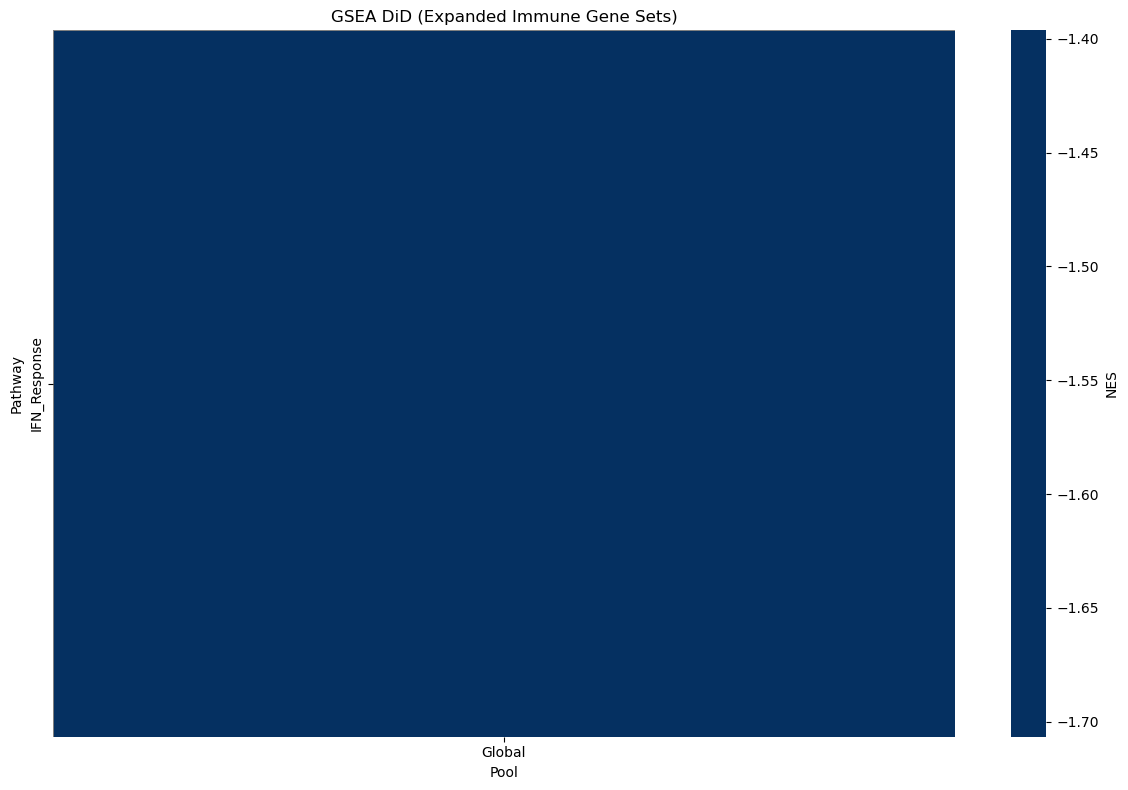

In [11]:
gene_sets = {}

# Expanded immune pathways for a more robust GSEA benchmark (real genes only)
expanded_sets = {
    "Cytotoxicity": ["GZMB", "GZMA", "GZMH", "PRF1", "GNLY", "NKG7", "IFNG"],
    "Exhaustion": ["PDCD1", "LAG3", "HAVCR2", "TIGIT", "CTLA4", "ENTPD1", "TOX"],
    "IFN_Response": ["ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", "MX1", "MX2", "STAT1", "OAS1", "IRF7"],
    "T_Cell_Activation": ["CD69", "CD38", "HLA-DRA", "ICOS", "IL2RA", "TNFRSF9"],
    "Memory_T": ["IL7R", "TCF7", "LEF1", "CCR7", "SELL", "CD27", "CD28"],
    "B_Cell_Response": ["CD79A", "CD79B", "MS4A1", "MZB1", "XBP1", "JCHAIN"],
    "Antigen_Presentation": ["HLA-DRA", "HLA-DRB1", "HLA-DPA1", "HLA-DPB1", "CD74"],
    "Myeloid_Inflammation": ["S100A8", "S100A9", "LYZ", "VCAN", "IL1B", "CXCL8"],
    "NK_Markers": ["NKG7", "KLRD1", "KLRB1", "GNLY", "PRF1"],
    "Chemokines": ["CCL2", "CCL3", "CCL4", "CCL5", "CXCL9", "CXCL10", "CXCL11"],
    "Cell_Cycle": ["MKI67", "TOP2A", "TYMS", "MCM5", "MCM6", "MCM7"],
    "Apoptosis": ["BAX", "BCL2", "CASP3", "CASP8", "FAS", "FASLG"],
    "Costimulation": ["CD27", "CD28", "TNFRSF4", "TNFRSF9", "ICOS"],
}

for k, genes in expanded_sets.items():
    present = [g for g in genes if g in adata_paired.var_names]
    if len(present) >= MIN_GENES_FOR_SCORE:
        gene_sets[k] = present

print(f"GSEA gene sets available: {len(gene_sets)}")

if gene_sets:
    start = time.perf_counter()
    gsea_res = st.run_gsea_did(
        adata_paired,
        gene_sets=gene_sets,
        design=design,
        visits=tuple(visits),
        min_size=MIN_GENES_FOR_SCORE,
    )
    benchmark_times["gsea_did"] = time.perf_counter() - start

    if gsea_res is not None and not gsea_res.empty:
        st.plot_gsea_heatmap(
            gsea_res,
            title="GSEA DiD (Expanded Immune Gene Sets)",
            figsize=(12, 8),
            fdr_thresh=0.25,
            top_n=25,
        )
        plt.show()
    else:
        print("GSEA returned no results after filtering.")
else:
    print("No gene sets available for GSEA.")


BENCHMARK SUMMARY

Timing summary (seconds):
  abundance_did: 0.00
  cross_sectional_Post: 0.27
  cross_sectional_Pre: 0.21
  did_genomewide: 5.58
  did_signatures: 0.55
  gsea_did: 135.91
  load_data: 1.34
  within_arm_Non-responder: 0.68
  within_arm_Responder: 0.27

  TOTAL: 144.80 seconds

SCALABILITY METRICS

Dataset size:
  - Cells: 7,068
  - Genes: 55,737
  - Paired participants: 10
  - Signatures tested: 5

Performance:
  - Cells per second (load): 5276
  - Genes per second (DiD): 359



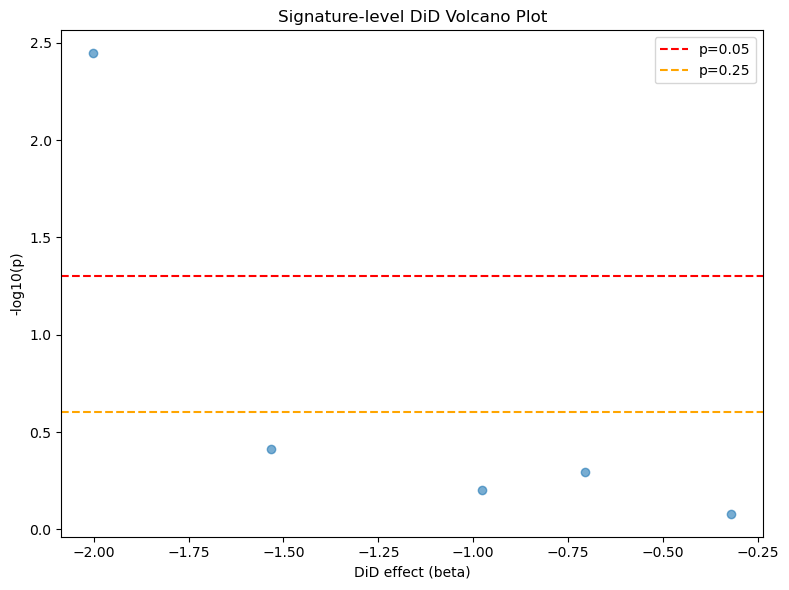

In [12]:
print("=" * 60)
print("BENCHMARK SUMMARY")
print("=" * 60)

print("\nTiming summary (seconds):")
for k, v in sorted(benchmark_times.items()):
    print(f"  {k}: {v:.2f}")

total_time = sum(benchmark_times.values())
print(f"\n  TOTAL: {total_time:.2f} seconds")

print("\n" + "=" * 60)
print("SCALABILITY METRICS")
print("=" * 60)

print(f"""
Dataset size:
  - Cells: {adata_paired.n_obs:,}
  - Genes: {adata_paired.n_vars:,}
  - Paired participants: {N_VALID_PAIRED}
  - Signatures tested: {len(signature_cols)}

Performance:
  - Cells per second (load): {adata_paired.n_obs / benchmark_times.get('load_data', 1):.0f}
  - Genes per second (DiD): {MAX_GENES_FOR_DID / benchmark_times.get('did_genomewide', 1):.0f}
""")

# Volcano plot with error handling
if did_results is not None and not did_results.empty:
    valid_did = did_results[did_results["beta_DiD"].notna() & did_results["p_DiD"].notna()]
    if not valid_did.empty:
        try:
            from sctrial.plotting import did_volcano_frame

            v = did_volcano_frame(valid_did)
            plt.figure(figsize=(8, 6))
            plt.scatter(v["beta_DiD"], v["neglog10p"], alpha=0.6)
            plt.axhline(-np.log10(0.05), color="red", linestyle="--", label="p=0.05")
            plt.axhline(-np.log10(FDR_ALPHA), color="orange", linestyle="--", label=f"p={FDR_ALPHA}")
            plt.title("Signature-level DiD Volcano Plot")
            plt.xlabel("DiD effect (beta)")
            plt.ylabel("-log10(p)")
            plt.legend()
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Could not generate volcano plot: {e}")
    else:
        print("No valid DiD results for volcano plot.")
else:
    print("No DiD results available for volcano plot.")